#! get data from video with drawings for detections to go with detections.csv file

In [3]:
# import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA


In [4]:
df = pd.read_csv('./dataset/detections-5.csv')
# df = pd.read_csv('./dataset/detections-6.csv')

print(df.shape)
print(df.head(5))
print(df.describe())
#* df['x1'] = df['x1'].str.replace(r'\D', '', regex=True) # caught some extra 'n' and 'q' chars from terminal (fix later, what if it was a number instead...)
print(df.columns)
# print(df.T)


(5721, 10)
    x1   y1   x2   y2  confidence   class_name  tracker_id  recording_name  \
0  428  210  457  241       0.869  hummingbird           1  detect_096.mp4   
1  420  211  446  235       0.825  hummingbird           1  detect_096.mp4   
2  411  214  439  237       0.845  hummingbird           1  detect_096.mp4   
3  413  215  438  239       0.855  hummingbird           1  detect_096.mp4   
4  412  219  441  237       0.491  hummingbird           1  detect_096.mp4   

   frame_time  frame_num  
0          66          2  
1         133          3  
2         200          4  
3         266          5  
4         333          6  
                x1           y1           x2           y2   confidence  \
count  5721.000000  5721.000000  5721.000000  5721.000000  5721.000000   
mean    410.257647   221.669114   427.814193   243.039504     0.787359   
std      30.744293    15.046284    31.702208    15.189301     0.057764   
min     200.000000   148.000000   211.000000   174.000000     

In [6]:
plt.rcParams['figure.figsize'] = (4, 2)
# np round not working here...
pca = PCA(n_components=1)
df['xy_pca'] = np.round(pca.fit_transform(df[['x1','x2','y1', 'y2']]),2)
df['center_x'] = abs(df['x1']-df['x2'])
df['center_y'] = abs(df['y1']-df['y2'])
# df['center_pca'] = np.round(pca.fit_transform(df[['center_x', 'center_y']]),2) # no good
if 'frame_time' in df.columns: df.drop('frame_time', axis=1, inplace=True)


num_cols = df.select_dtypes(include='number').columns.tolist()
# df_non_numeric = df.drop(columns=num_cols)

cols = ['xy_pca', 'center_x', 'center_y']
df[cols] = (df[cols]-df[cols].min())/(df[cols].max()-df[cols].min())

# df[num_cols]
print(df)




# print(df)
# print(normalized)
# df.columns

       x1   y1   x2   y2  confidence   class_name  tracker_id  recording_name  \
0     428  210  457  241       0.869  hummingbird           1  detect_096.mp4   
1     420  211  446  235       0.825  hummingbird           1  detect_096.mp4   
2     411  214  439  237       0.845  hummingbird           1  detect_096.mp4   
3     413  215  438  239       0.855  hummingbird           1  detect_096.mp4   
4     412  219  441  237       0.491  hummingbird           1  detect_096.mp4   
...   ...  ...  ...  ...         ...          ...         ...             ...   
5716  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5717  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5718  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5719  409  220  422  242       0.718  hummingbird          56    rec_1206.mp4   
5720  410  221  424  242       0.711  hummingbird          56    rec_1206.mp4   

      frame_num    xy_pca  

In [11]:
# df.describe()
conf_df = df[df['confidence'] > .8]

name: detect_096.mp4


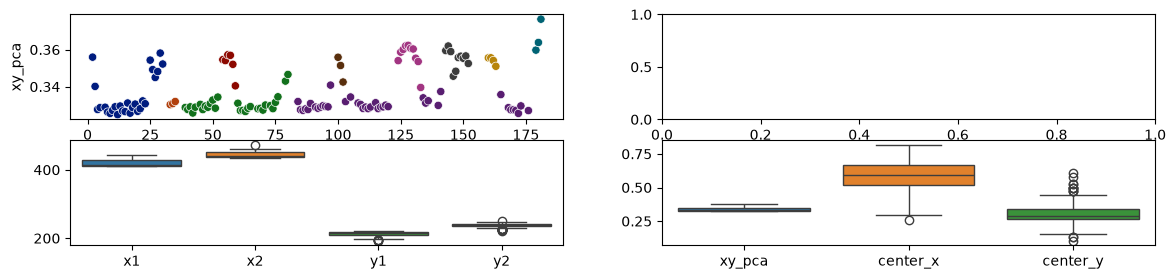

name: detect_097.mp4


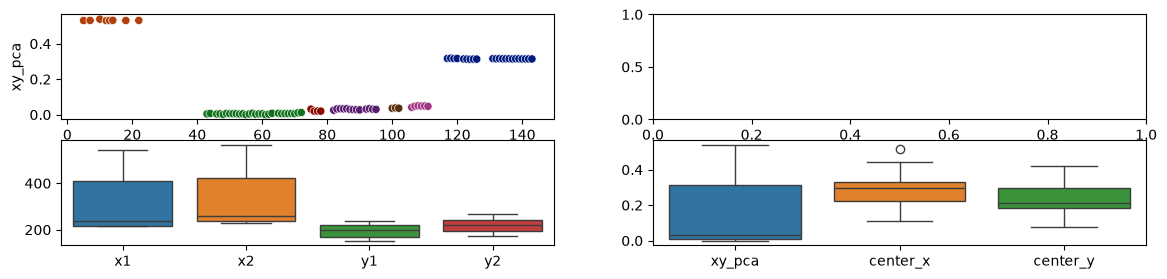

name: detect_098.mp4


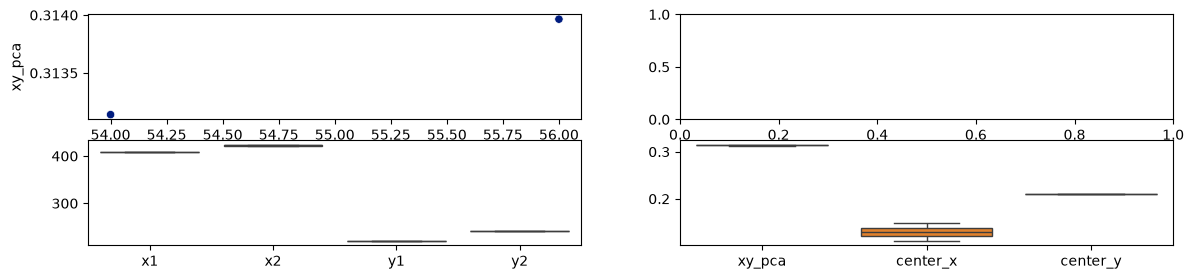

name: detect_108.mp4


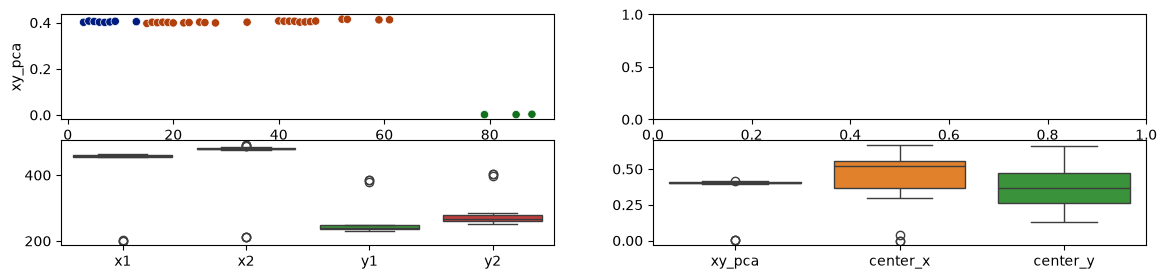

name: detect_109.mp4


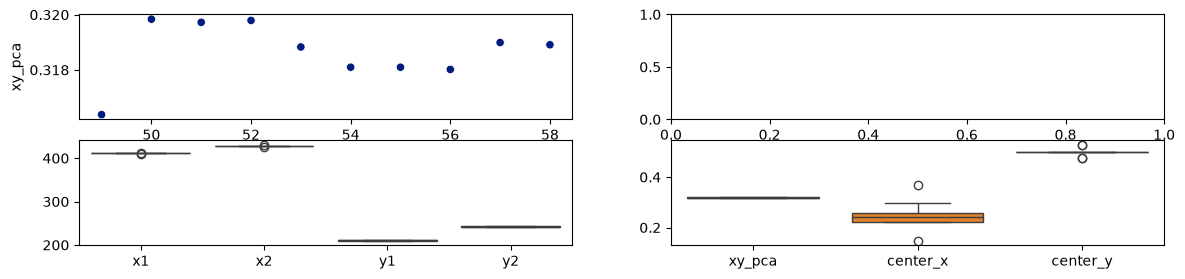

name: detect_112.mp4


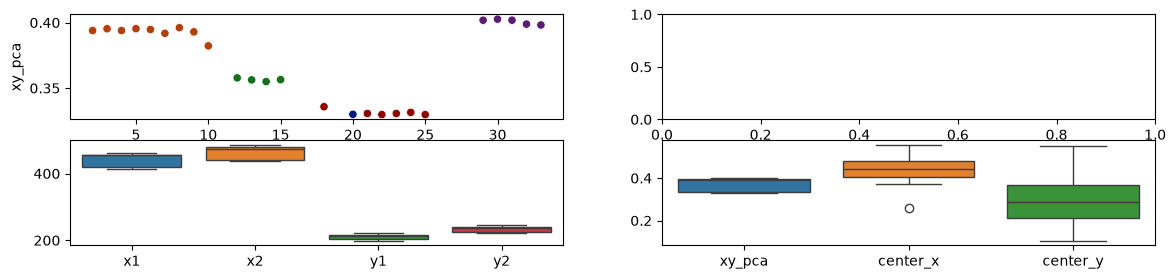

name: detect_117.mp4


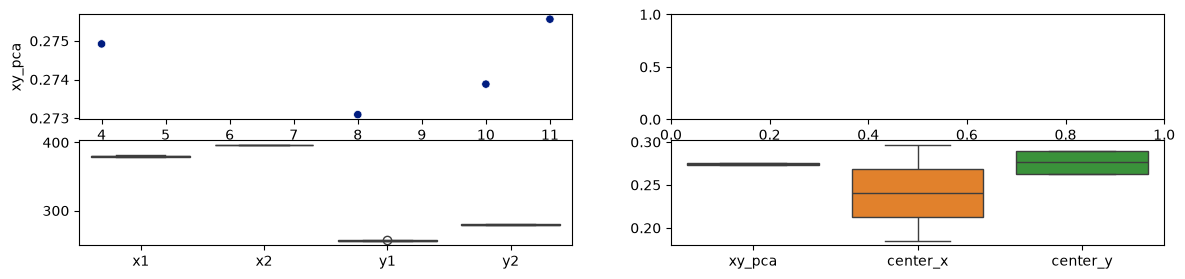

name: detect_123.mp4


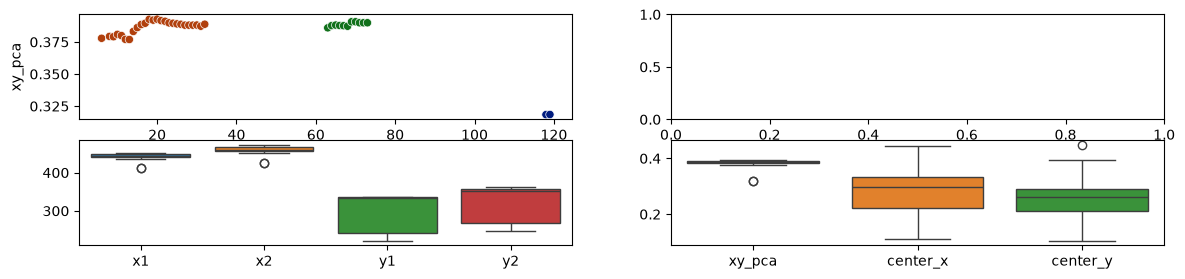

name: detect_125.mp4


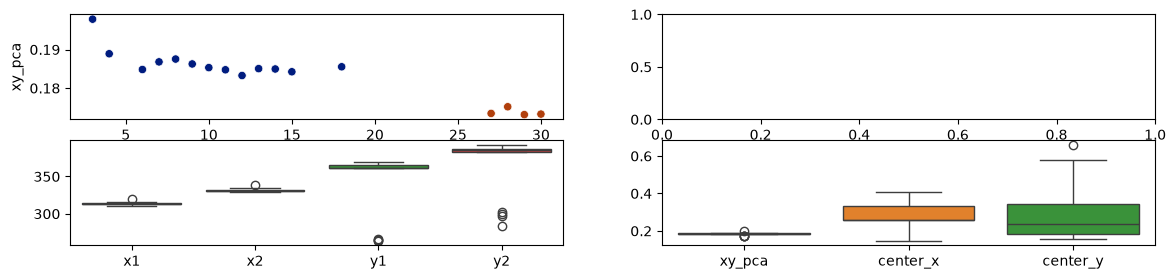

name: detect_129.mp4


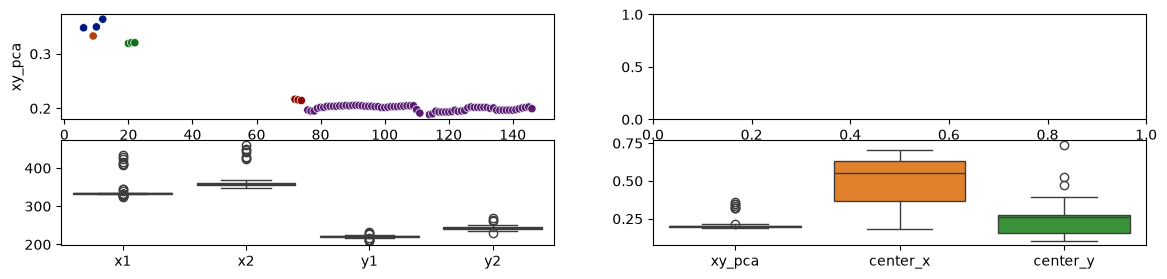

name: detect_151.mp4


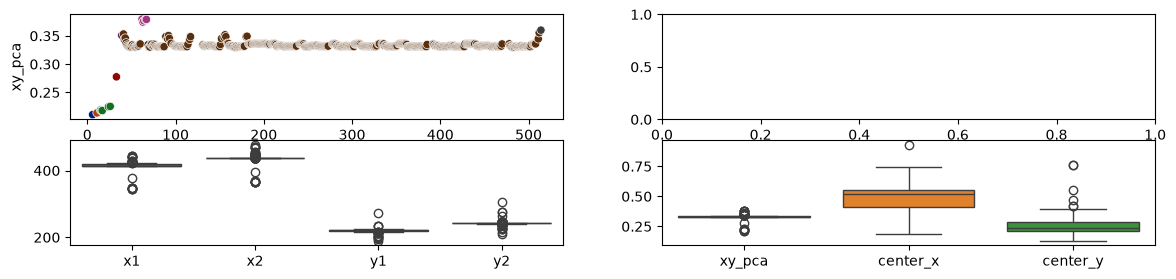

In [13]:

# sns.scatterplot(x=df['x1'], y=df['y1'], hue=df['tracker_id'], palette='Reds')
# plt.show()

# sns.scatterplot(x=pd['frame_num'], y=pd['xy_pca'], hue=pd['tracker_id'], palette='Reds')

# sns.boxplot(x=df['x1'], y=df['y1'])

# sns.lineplot(x=df['x1'], y=df['y1'])
# sns.heatmap(data = df[['x1', 'y1', 'tracker_id']])
# plt.show()
# corr = df.corr(numeric=True)
# sns.heatmap(data=corr, cmap='coolwarm')
# plt.show()


# fig, axes = plt.subplots(3,3, figsize=(10,5))

i = 0
for name, group in conf_df.groupby('recording_name'):
    if i > 10: break
    i+=1
    print(f'name: {name}')
    # plt.figure(figsize=(4,2))
    fig, axes = plt.subplots(2,2, figsize=(14, 3))

    sns.scatterplot(x=group['frame_num'], y=group['xy_pca'], hue=group['tracker_id'], palette='dark', ax=axes[0][0], legend=False)
    # sns.scatterplot(x=group['frame_num'], y=group['center_pca'], hue=group['tracker_id'], palette='dark', ax=axes[0][1])
    # sns.scatterplot(x=group['x1'], y=group['y1'], hue=group['tracker_id'], palette='deep', ax=axes[0][1])
    sns.boxplot(data=group[['x1','x2','y1','y2',]], ax=axes[1][0])
    sns.boxplot(data=group.drop(labels=['x1','x2','y1','y2','frame_num','confidence','tracker_id'], axis=1), ax=axes[1][1])


#line graph with all trackers on on graph
#get distance from each tracker cluster and within timeframe

    plt.show()


From these graphs, I want to conclude that using xy_pca will be the most effective method to determine grouping going when going from frame to frame. It has the least amount of variance and the outliers seem to be other trackers

name: detect_096.mp4


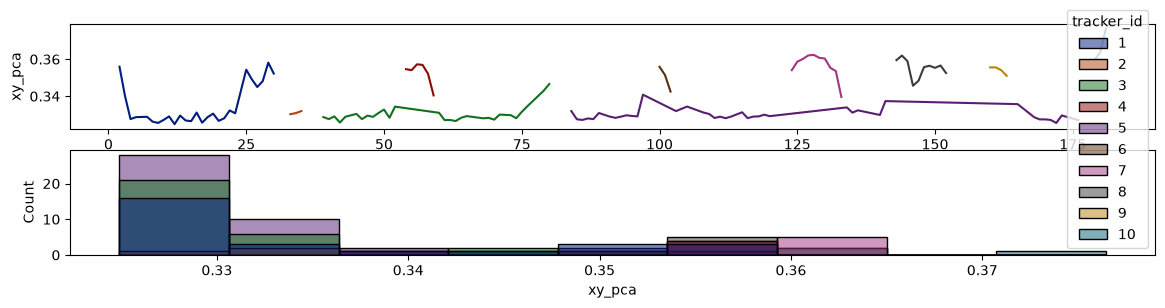

name: detect_097.mp4


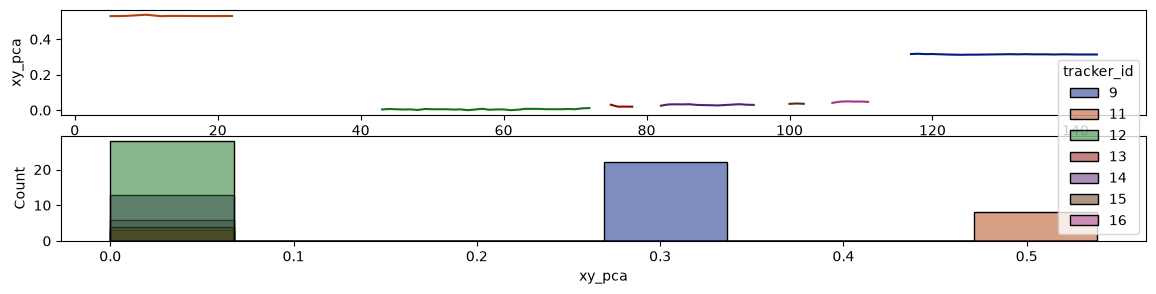

name: detect_098.mp4


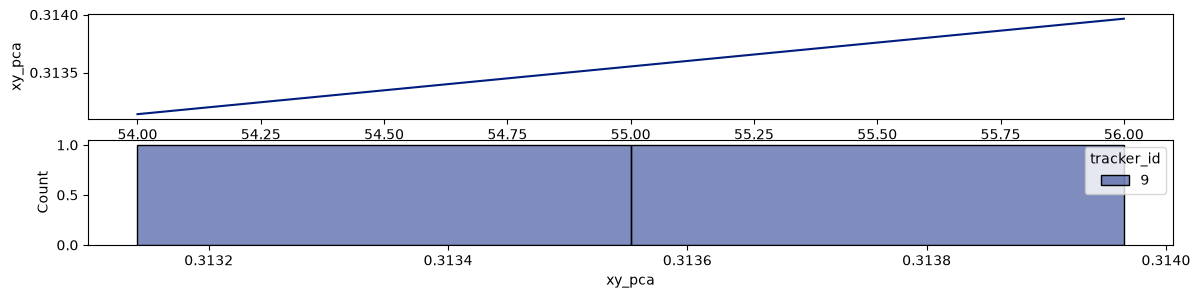

name: detect_108.mp4


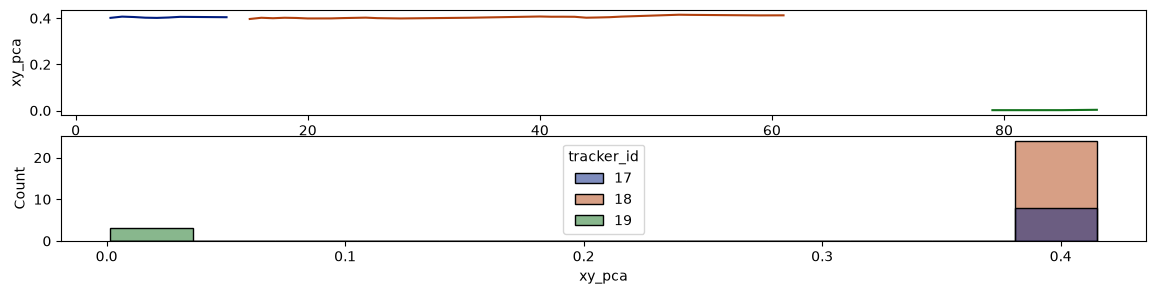

name: detect_109.mp4


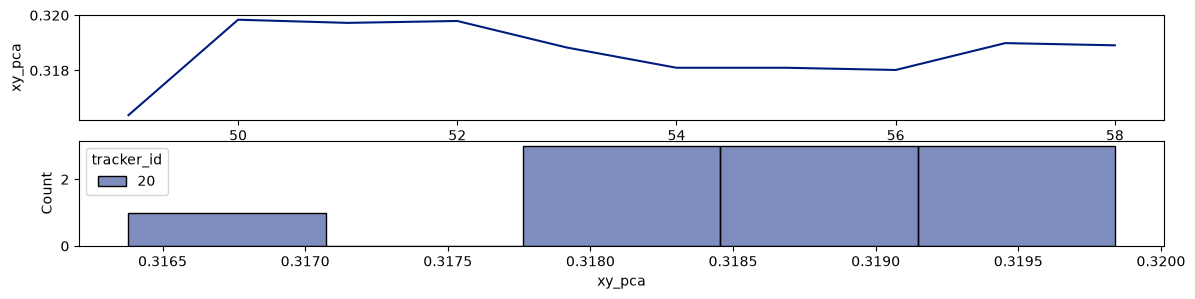

name: detect_112.mp4


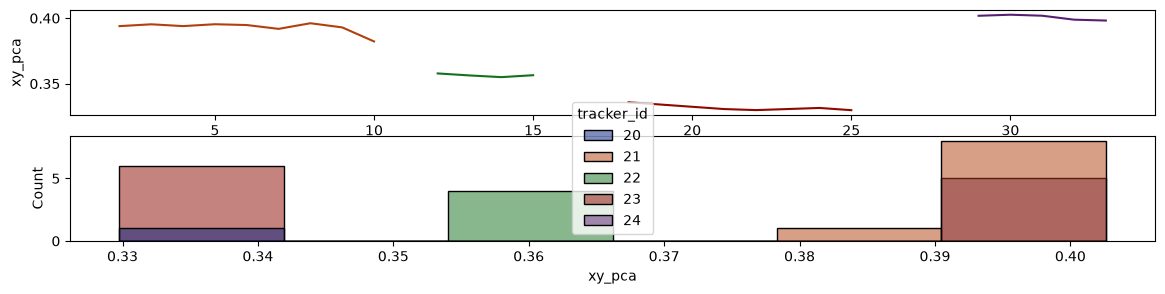

name: detect_117.mp4


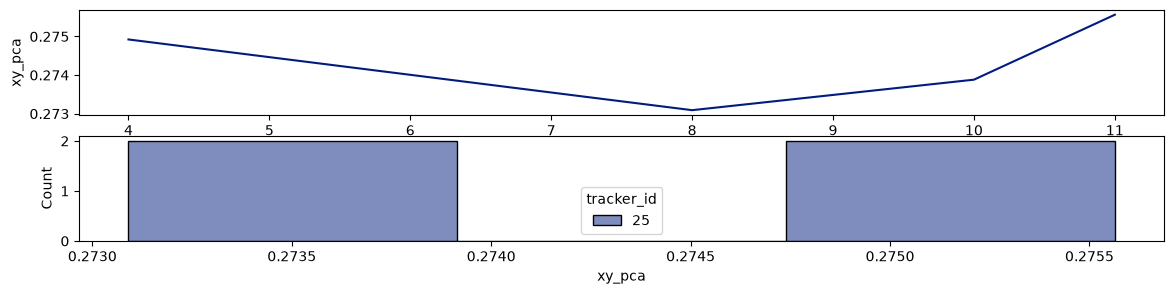

name: detect_123.mp4


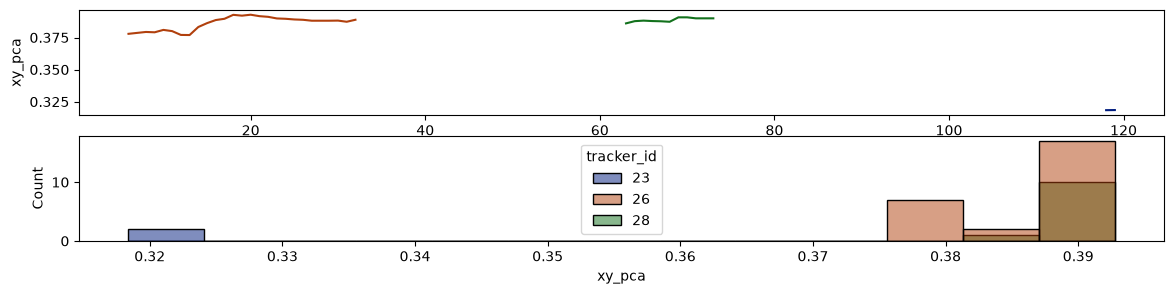

name: detect_125.mp4


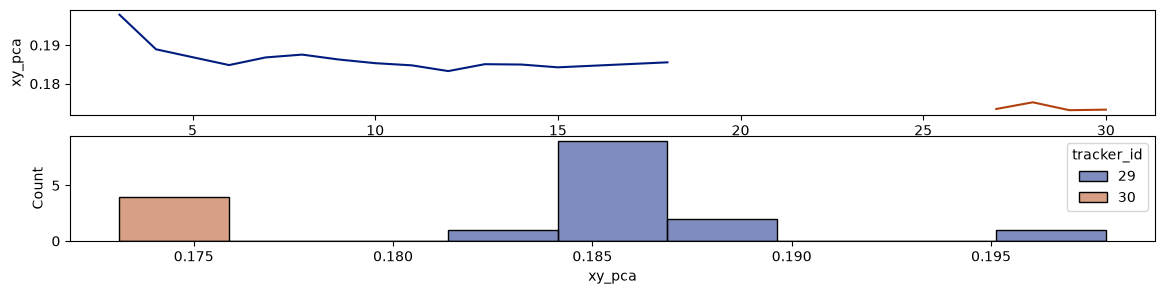

name: detect_129.mp4


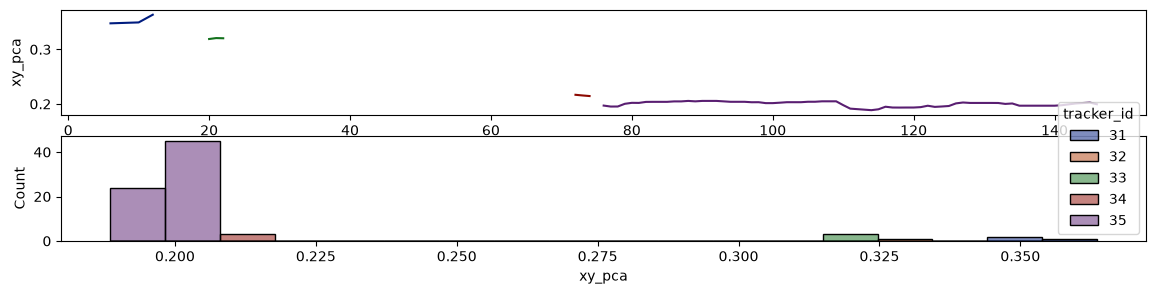

name: detect_151.mp4


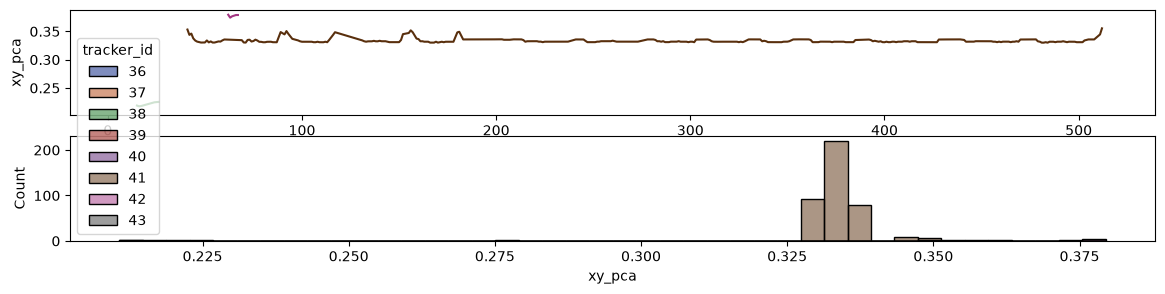

name: detect_166.mp4


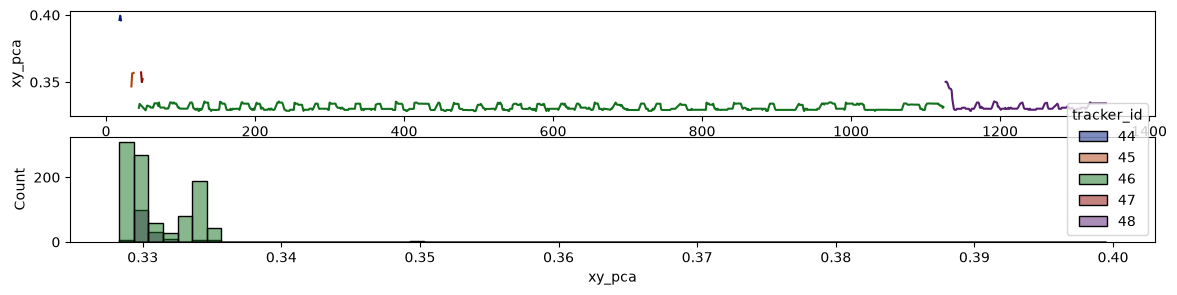

name: rec_1206.mp4


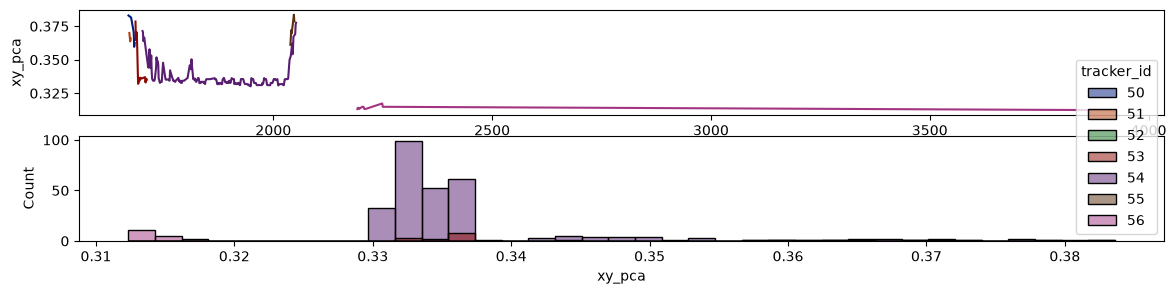

In [ ]:
i=0
for name, group in conf_df.groupby('recording_name'):
    if i > 14: break
    i+=1
    print(f'name: {name}')
    # plt.figure(figsize=(4,2))
    # fig, axes = plt.subplots(2,2, figsize=(14, 3))
    fig, axes = plt.subplots(2,1, figsize=(14, 3))

    sns.lineplot(x=group['frame_num'], y=group['xy_pca'], hue=group['tracker_id'], palette='dark', ax=axes[0], legend=False)
    sns.histplot(group[['frame_num','xy_pca','tracker_id']], x='xy_pca', hue='tracker_id', palette='dark')
    plt.show()

In [53]:

X = df[['x1','x2','y1', 'y2', 'confidence']]
y = df[['tracker_id']]
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

X2 = df[['x1', 'y1', 'x2', 'y2', 'confidence', 'frame_num', 'xy_pca']]
y2 = df[['tracker_id']]
X2_train,X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=.2)

model = KNeighborsClassifier()
model.fit(X_train, y_train)
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f'train: {train_score:.2f} test: {test_score:.2f} report:\n')

model = KNeighborsClassifier()
model.fit(X2_train, y2_train)
train_score = model.score(X2_train,y2_train)
test_score = model.score(X2_test,y2_test)
print(f'train2: {train_score:.2f} test2: {test_score:.2f} report:\n')


/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


train: 0.91 test: 0.87 report:

train2: 0.98 test2: 0.94 report:



/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [40]:

estimator = KNeighborsClassifier()
param_grid={
    'n_neighbors':(2,4,5,8,10),
    'weights':('uniform', 'distance'),
    'leaf_size':(1,20,30),
    'p':(1,2),
    'metric':('minkowski','chebyshev')
}
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision',
#     'recall': 'recall',
#     'f1': 'f1',
# }
grid = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=5
)

grid.fit(X_train, y_train)
print('best params',grid.best_params_)
print('best score ',grid.best_score_)

# best_params = {'leaf_size': 1, 'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
best_params = grid.best_params_
model = KNeighborsClassifier(**best_params)
model.fit(X_train,y_train)

train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f'train: {train_score:.2f} test: {test_score:.2f}')


/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/braden/miniconda3/envs/bird-cam/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

best params {'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
best score  0.8417820411864365
train: 0.89 test: 0.84
